In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#style
sns.set(style="whitegrid")

#load data
df = pd.read_csv("../data/spotify_churn_dataset.csv")

df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [ ]:
#1.) Which age demographics are listening to the most ads?

bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18','18-25', '26-35', '36-45', '46-60', '60+']  

#converting continuous numbers into categories
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


In [30]:
df[['age', 'age_group']].head()

,age,age_group
0,54,46-60
1,33,26-35
2,38,36-45
3,22,18-25
4,29,26-35


In [44]:
#we use mean to tell us average exposure per user
ads_by_age = df.groupby('age_group')['ads_listened_per_week'].mean()
ads_by_age


age_group
<18      7.322097
18-25    7.000000
26-35    6.830937
36-45    7.121951
46-60    6.791381
Name: ads_listened_per_week, dtype: float64

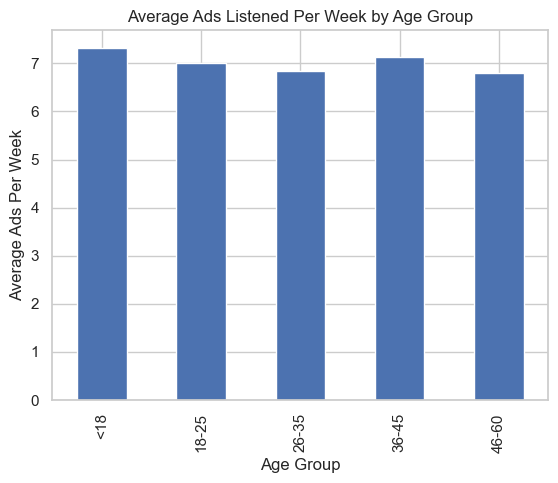

In [32]:
plt.figure()
ads_by_age.plot(kind='bar')
plt.title("Average Ads Listened Per Week by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Ads Per Week")
plt.show()

In [33]:
#2.) Do free users skip songs at a higher rate than premium users?

skip_by_sub = df.groupby('subscription_type')['skip_rate'].mean()
skip_by_sub
#average skip rate by subscription type

subscription_type
Family     0.300325
Free       0.300922
Premium    0.296582
Student    0.302945
Name: skip_rate, dtype: float64

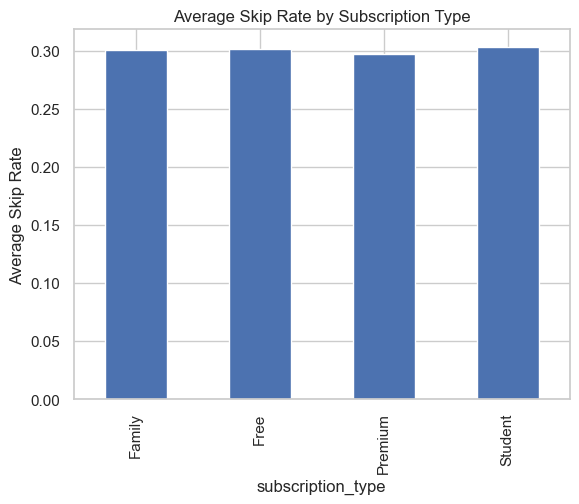

In [34]:
plt.figure()
skip_by_sub.plot(kind='bar')
plt.title("Average Skip Rate by Subscription Type")
plt.ylabel("Average Skip Rate")
plt.show()

In [36]:
#3.) Show engagement by subscription type

engagement = df.groupby('subscription_type')[['listening_time', 'songs_played_per_day', 'ads_listened_per_week']].mean()

engagement
#average engagement features

,listening_time,songs_played_per_day,ads_listened_per_week
subscription_type,,,
Family,151.041405,50.383124,0.00000
Free,154.997027,49.204163,27.52775
Premium,155.522931,49.744681,0.00000
Student,154.489025,51.241960,0.00000


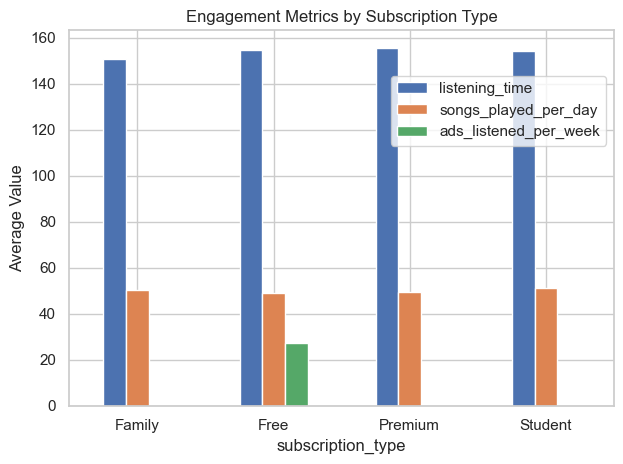

In [37]:
engagement.plot(kind='bar')
plt.title("Engagement Metrics by Subscription Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(loc = 'upper right', bbox_to_anchor = (1.0,0.9))
plt.show()

In [38]:
#4.) Is lower engagment linked to churn?
df.groupby('is_churned')[
    ['listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']].mean()

,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week
is_churned,,,,
0,154.446787,49.970653,0.298474,6.962220
1,152.984549,50.575567,0.304862,6.891357


In [39]:
#4a.) Does subcription type affect churn rate?
df.groupby('subscription_type')['is_churned'].mean()
#churn percentage by plan

subscription_type
Family     0.275157
Free       0.249257
Premium    0.250591
Student    0.261868
Name: is_churned, dtype: float64

In [40]:
#4b.) Does age affect churn?
df.groupby('age_group')['is_churned'].mean()
#churn percentage by age

age_group
<18      0.258427
18-25    0.242890
26-35    0.276021
36-45    0.253326
46-60    0.259344
Name: is_churned, dtype: float64

In [ ]:
#4c.) Does gender affect churn?
df.groupby('gender')['is_churned'].mean()
#churn percentage by gender

gender
Female    0.262881
Male      0.251951
Other     0.261887
Name: is_churned, dtype: float64

In [41]:
df.corr(numeric_only=True)
#calculating correlation between numeric columns such as churn

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
user_id,1.000000,0.011728,-0.012948,0.024827,0.011637,-0.005517,0.002199,-0.015994
age,0.011728,1.000000,-0.012975,-0.006834,-0.019557,-0.011962,0.017061,0.003982
listening_time,-0.012948,-0.012975,1.000000,-0.010996,-0.013603,0.002279,-0.006421,-0.007624
songs_played_per_day,0.024827,-0.006834,-0.010996,1.000000,-0.000590,-0.017813,0.018846,0.009314
skip_rate,0.011637,-0.019557,-0.013603,-0.000590,1.000000,-0.012682,-0.002657,0.016121
ads_listened_per_week,-0.005517,-0.011962,0.002279,-0.017813,-0.012682,1.000000,-0.877970,-0.002279
offline_listening,0.002199,0.017061,-0.006421,0.018846,-0.002657,-0.877970,1.000000,0.012754
is_churned,-0.015994,0.003982,-0.007624,0.009314,0.016121,-0.002279,0.012754,1.000000


In [42]:
df['is_churned'].value_counts(normalize=True)
#determines if the data is imbalanced

is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64

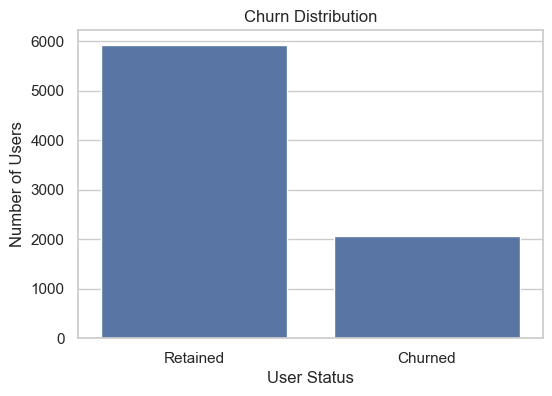

In [43]:
# Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='is_churned', data=df)

plt.title("Churn Distribution")
plt.xticks([0,1], ['Retained', 'Churned'])
plt.ylabel("Number of Users")
plt.xlabel("User Status")

plt.show()

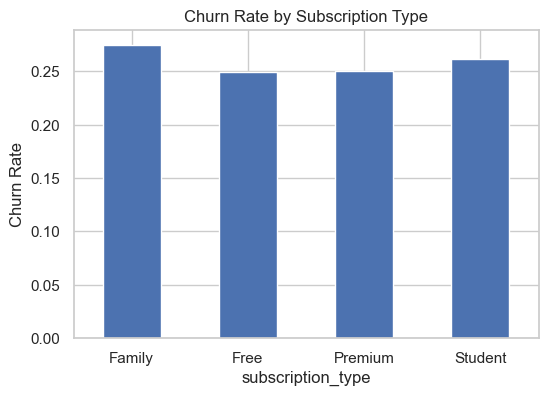

In [ ]:
#Churn Rate by Subscription 
churn_sub = df.groupby('subscription_type')['is_churned'].mean()

plt.figure(figsize=(6,4))
churn_sub.plot(kind='bar')

plt.title("Churn Rate by Subscription Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)

plt.show()